Julia notebook to test out the 0D floc mod equations.

In [ ]:
using Printf
using DataStructures: OrderedDict
using NCDatasets
using CSV, DataFrames
using Printf
using Profile
using Statistics 
# using Arrow, DataFrames
using LaTeXStrings
using LinearAlgebra
using Plots


include("floc_mod.jl")
using .floc_mod
# Pkg.add(["LaTeXStrings", "LinearAlgebra", "Profile"])
# println("hello")

In [2]:
# ********************** DEFINE SEDIMENT SIZE CLASSES ****************************
Ns = 100                  # Number of sediment size classes

D = LinRange(1e-1, 200, Ns) .* 1e-6     # Sediment grain sizes (\mu m )
D = collect(D)
println("Sediment grain sizes (m) = ", D)

# initialize once
init_params!(D, Ns)

# Calculate settling velocities for each size class
ws = floc_mod.ws[] 
println("Settling velocities (m/s) = ", ws)



Sediment grain sizes (m) = [1.0e-7, 2.119191919191919e-6, 4.138383838383838e-6, 6.157575757575757e-6, 8.176767676767677e-6, 1.0195959595959595e-5, 1.2215151515151514e-5, 1.4234343434343433e-5, 1.6253535353535352e-5, 1.8272727272727275e-5, 2.029191919191919e-5, 2.231111111111111e-5, 2.433030303030303e-5, 2.634949494949495e-5, 2.8368686868686863e-5, 3.0387878787878786e-5, 3.240707070707071e-5, 3.442626262626262e-5, 3.644545454545455e-5, 3.846464646464645e-5, 4.048383838383838e-5, 4.2503030303030304e-5, 4.4522222222222216e-5, 4.6541414141414136e-5, 4.8560606060606055e-5, 5.057979797979798e-5, 5.25989898989899e-5, 5.461818181818181e-5, 5.663737373737373e-5, 5.865656565656565e-5, 6.0675757575757576e-5, 6.26949494949495e-5, 6.471414141414141e-5, 6.673333333333332e-5, 6.875252525252524e-5, 7.077171717171717e-5, 7.279090909090909e-5, 7.4810101010101e-5, 7.682929292929292e-5, 7.884848484848483e-5, 8.086767676767675e-5, 8.288686868686867e-5, 8.49060606060606e-5, 8.692525252525252e-5, 8.894444444

┌ Info: Initializing flocculation model with 100 sediment classes ...
└ @ Main.floc_mod /global/homes/s/siennaw/scratch/siennaw/scripts/enkf_sediment/floc_mod.jl:32
┌ Info: 	 initialized density, settling velocity, and floc mass...
└ @ Main.floc_mod /global/homes/s/siennaw/scratch/siennaw/scripts/enkf_sediment/floc_mod.jl:39


Settling velocities (m/s) = [1.0605792767949334e-9, 2.19264771195582e-6, 1.1684767096365646e-5, 3.155495362863058e-5, 6.412055653938062e-5, 0.00011133030566670052, 0.00017490019055653076, 0.0002563815310666155, 0.0003572010588221494, 0.00047868692767264305, 0.0006220867444109206, 0.000788580683210884, 0.0009792913807123848, 0.0011952916215972663, 0.0014376104499880334, 0.001707238124585044, 0.0020051302026739275, 0.00233221095357601, 0.002689376246342103, 0.003077496018586852, 0.0034974164069276133, 0.003949961600637149, 0.004435935466401318, 0.004956122981914169, 0.005511291508400893, 0.006102191926328309, 0.0067295596540563425, 0.007394115565660617, 0.008096566821372194, 0.00883760762185876, 0.009617919895782867, 0.010438173928620734, 0.011299028939537097, 0.01220113361213293, 0.013145126584071121, 0.014131636899907587, 0.015161284430887014, 0.016234680264982343, 0.017352427070049994, 0.01851511943262615, 0.01972334417459215, 0.020977680649681803, 0.022278701021582713, 0.023626970525

┌ Info: 	 initialized collision matrix, half-mass indices, and D ratio for break-up ...
└ @ Main.floc_mod /global/homes/s/siennaw/scratch/siennaw/scripts/enkf_sediment/floc_mod.jl:60


In [ ]:
ssc0 = zeros(Ns) .+ 1e6     # Matrix for sediment concentration (Nz x Ns)

turbulent_shear = 0.5

let N1=ssc0
anim = @animate for i in 1:10
    println(i)
    N1 = run_floc_mod(N1, Ns, turbulent_shear)
    scatter(D, N1,  title="Frame $i", legend=false) #xlim=(0,1), ylim=(0,1),
end
end 
gif(anim, "animated_scatter.gif", fps = 15)


┌ Error: CAUTION: all floc sizes have negative mass! 
└ @ Main.floc_mod /global/homes/s/siennaw/scratch/siennaw/scripts/enkf_sediment/floc_mod.jl:276


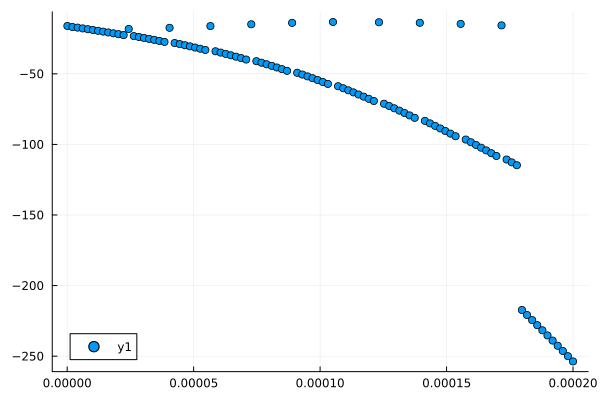

In [10]:
scatter(D, ssc0)
scatter(D, N1)